# PKCERT AI & Software Development Internship, Task 17
# Neural Network Fundamentals: Perceptron, Activation Functions & Backpropagation

A from-scratch (NumPy-only) implementation of a perceptron, five activation functions
with their derivatives, and a 2-layer MLP trained with hand-derived backpropagation --
benchmarked against a scikit-learn `MLPClassifier` baseline. No autograd framework
(TensorFlow / PyTorch / Keras) computes any gradient anywhere in this notebook; the only
place scikit-learn appears is the permitted baseline comparison and ordinary
preprocessing/evaluation utilities (train/test split, scaling, metrics).

In [1]:
%matplotlib inline
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

## Part A: Perceptron Fundamentals

A single-layer perceptron, trained with the classic perceptron learning rule
$w \leftarrow w + \eta (y - \hat{y})\,x$, using a hard step activation. This is pure
NumPy: no scikit-learn, TensorFlow or PyTorch is used for the model or its training.

In [2]:
class Perceptron:
    def __init__(self, n_features, learning_rate=0.1, n_epochs=20):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.history = []
        self.errors_per_epoch = []

    @staticmethod
    def _step(z):
        return np.where(z >= 0, 1, 0)

    def predict(self, X):
        return self._step(X @ self.w + self.b)

    def fit(self, X, y):
        self.history.append((self.w.copy(), self.b))
        for epoch in range(self.n_epochs):
            errors = 0
            for xi, yi in zip(X, y):
                y_hat = self._step(xi @ self.w + self.b)
                update = self.lr * (yi - y_hat)
                if update != 0.0:
                    self.w += update * xi
                    self.b += update
                    errors += 1
            self.errors_per_epoch.append(errors)
            self.history.append((self.w.copy(), self.b))
            if errors == 0:
                break
        return self

**A2/A3: a linearly separable subset of Iris.** Setosa vs Versicolor, using petal length and width -- the textbook example of a cleanly separable pair in Iris.

In [3]:
iris = load_iris()
mask = iris.target < 2
X_iris = iris.data[mask][:, [2, 3]]
y_iris = iris.target[mask]
feat_names = ["petal length (cm)", "petal width (cm)"]

X_mean, X_std = X_iris.mean(axis=0), X_iris.std(axis=0)
X_iris_s = (X_iris - X_mean) / X_std
perm = rng.permutation(len(X_iris_s))
X_iris_s, y_iris = X_iris_s[perm], y_iris[perm]

p_iris = Perceptron(n_features=2, learning_rate=0.1, n_epochs=20)
p_iris.fit(X_iris_s, y_iris)
train_acc = (p_iris.predict(X_iris_s) == y_iris).mean()
print(f"Epochs to convergence: {len(p_iris.errors_per_epoch)} (errors per epoch: {p_iris.errors_per_epoch})")
print(f"Final training accuracy: {train_acc:.4f}")
print(f"Final weights: {p_iris.w}, bias: {p_iris.b:.4f}")

Epochs to convergence: 2 (errors per epoch: [2, 0])
Final training accuracy: 1.0000
Final weights: [0.15253599 0.10670077], bias: 0.0000


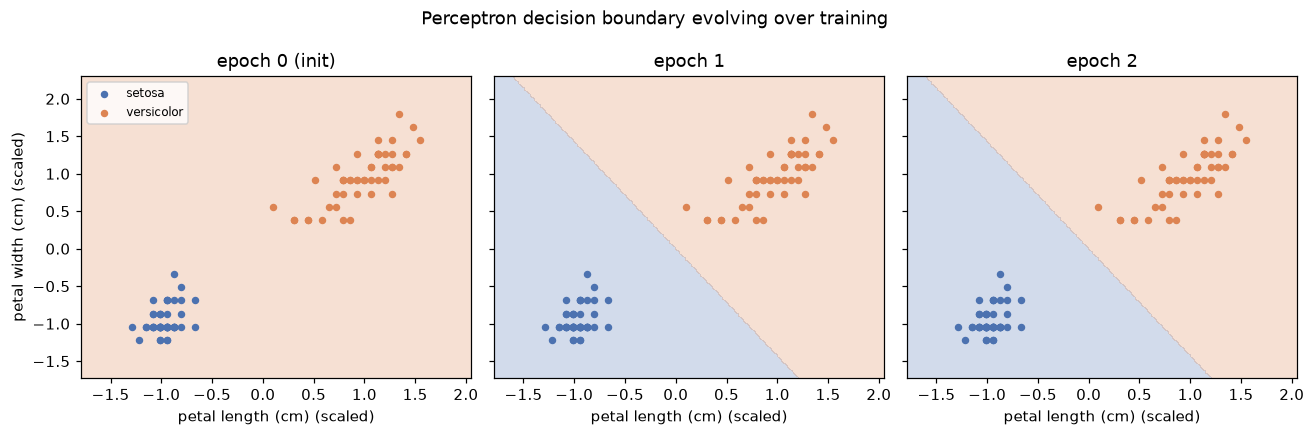

In [4]:
snapshot_epochs = sorted(set([0, 1, 2, len(p_iris.history) - 1]))
snapshot_epochs = [e for e in snapshot_epochs if e < len(p_iris.history)]
fig, axes = plt.subplots(1, len(snapshot_epochs), figsize=(4 * len(snapshot_epochs), 4), sharey=True)
xx, yy = np.meshgrid(np.linspace(X_iris_s[:, 0].min() - 0.5, X_iris_s[:, 0].max() + 0.5, 200),
                      np.linspace(X_iris_s[:, 1].min() - 0.5, X_iris_s[:, 1].max() + 0.5, 200))
for ax, e in zip(axes, snapshot_epochs):
    w_e, b_e = p_iris.history[e]
    Z = Perceptron._step((np.c_[xx.ravel(), yy.ravel()] @ w_e) + b_e).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, levels=[-0.5, 0.5, 1.5], colors=["#4C72B0", "#DD8452"])
    ax.scatter(X_iris_s[y_iris == 0, 0], X_iris_s[y_iris == 0, 1], s=15, color="#4C72B0", label="setosa")
    ax.scatter(X_iris_s[y_iris == 1, 0], X_iris_s[y_iris == 1, 1], s=15, color="#DD8452", label="versicolor")
    ax.set_title(f"epoch {e}" if e > 0 else "epoch 0 (init)")
    ax.set_xlabel(feat_names[0] + " (scaled)")
axes[0].set_ylabel(feat_names[1] + " (scaled)")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Perceptron decision boundary evolving over training")
fig.tight_layout()
plt.show()

**A4: the same perceptron on XOR.**

In [5]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])
p_xor = Perceptron(n_features=2, learning_rate=0.1, n_epochs=50)
p_xor.fit(X_xor, y_xor)
xor_acc = (p_xor.predict(X_xor) == y_xor).mean()
print(f"Ran the full {p_xor.n_epochs} epochs without reaching zero errors")
print(f"Errors per epoch: {p_xor.errors_per_epoch}")
print(f"Final training accuracy: {xor_acc:.4f}")

Ran the full 50 epochs without reaching zero errors
Errors per epoch: [3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
Final training accuracy: 0.5000


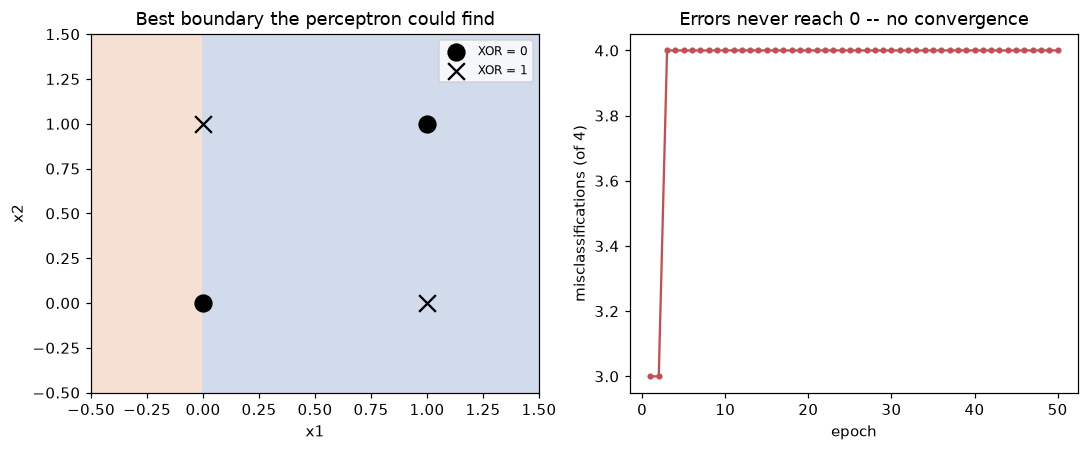

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
w_f, b_f = p_xor.history[-1]
xx2, yy2 = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
Z2 = Perceptron._step((np.c_[xx2.ravel(), yy2.ravel()] @ w_f) + b_f).reshape(xx2.shape)
ax[0].contourf(xx2, yy2, Z2, alpha=0.25, levels=[-0.5, 0.5, 1.5], colors=["#4C72B0", "#DD8452"])
for cls, marker in [(0, "o"), (1, "x")]:
    pts = X_xor[y_xor == cls]
    ax[0].scatter(pts[:, 0], pts[:, 1], s=120, marker=marker, color="black", label=f"XOR = {cls}")
ax[0].set_xlim(-0.5, 1.5); ax[0].set_ylim(-0.5, 1.5)
ax[0].set_xlabel("x1"); ax[0].set_ylabel("x2")
ax[0].set_title("Best boundary the perceptron could find")
ax[0].legend(fontsize=8)
ax[1].plot(range(1, len(p_xor.errors_per_epoch) + 1), p_xor.errors_per_epoch, marker="o", ms=3, color="#C44E52")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("misclassifications (of 4)")
ax[1].set_title("Errors never reach 0 -- no convergence")
fig.tight_layout()
plt.show()

**Why XOR defeats a single perceptron.** A perceptron's decision boundary is the
single hyperplane $w \cdot x + b = 0$. XOR's four points need two separate diagonal
boundaries -- $(0,0)$ and $(1,1)$ on one side, $(0,1)$ and $(1,0)$ on the other -- which
is not linearly separable in 2D. No choice of $w, b$ puts one straight line between
those classes, which is exactly what the flat error curve shows: the rule keeps fixing
one misclassified point only to break another.

**A5: Perceptron vs logistic regression.** Both are linear classifiers computing the
same score $z = w \cdot x + b$, and both learn by adjusting $w, b$ from labelled
examples. They differ in what happens to $z$, and how that is used to learn. The
perceptron applies a hard step -- predict 1 if $z \ge 0$ -- and updates weights only on
misclassified points, by an amount proportional to the raw error
$(y - \hat{y}) \in \{-1,0,1\}$; there is no smooth loss surface, only a mistake-driven
rule. Logistic regression applies the smooth sigmoid to $z$ to get a probability,
defines cross-entropy loss over it, and updates every point's weights by gradient
descent on that loss -- whose gradient takes the strikingly similar form
$(y-p)x$, except $p$ is a continuous probability, not a hard vote. As the sigmoid's
steepness goes to infinity, logistic regression's smooth boundary collapses to the
perceptron's hard one: the perceptron is, informally, the hard-threshold,
mistake-driven special case of the same linear model logistic regression fits with a
smooth, probabilistic loss.

## Part B: Activation Functions

Sigmoid, Tanh, ReLU, Leaky ReLU and Softmax, each implemented from scratch with its
derivative, using only NumPy.

In [7]:
def sigmoid(x): return 1.0 / (1.0 + np.exp(-x))
def sigmoid_deriv(x):
    s = sigmoid(x); return s * (1 - s)
def tanh(x): return np.tanh(x)
def tanh_deriv(x): return 1 - np.tanh(x) ** 2
def relu(x): return np.maximum(0, x)
def relu_deriv(x): return (x > 0).astype(float)
def leaky_relu(x, alpha=0.01): return np.where(x > 0, x, alpha * x)
def leaky_relu_deriv(x, alpha=0.01): return np.where(x > 0, 1.0, alpha)
def softmax(x, axis=-1):
    z = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=axis, keepdims=True)

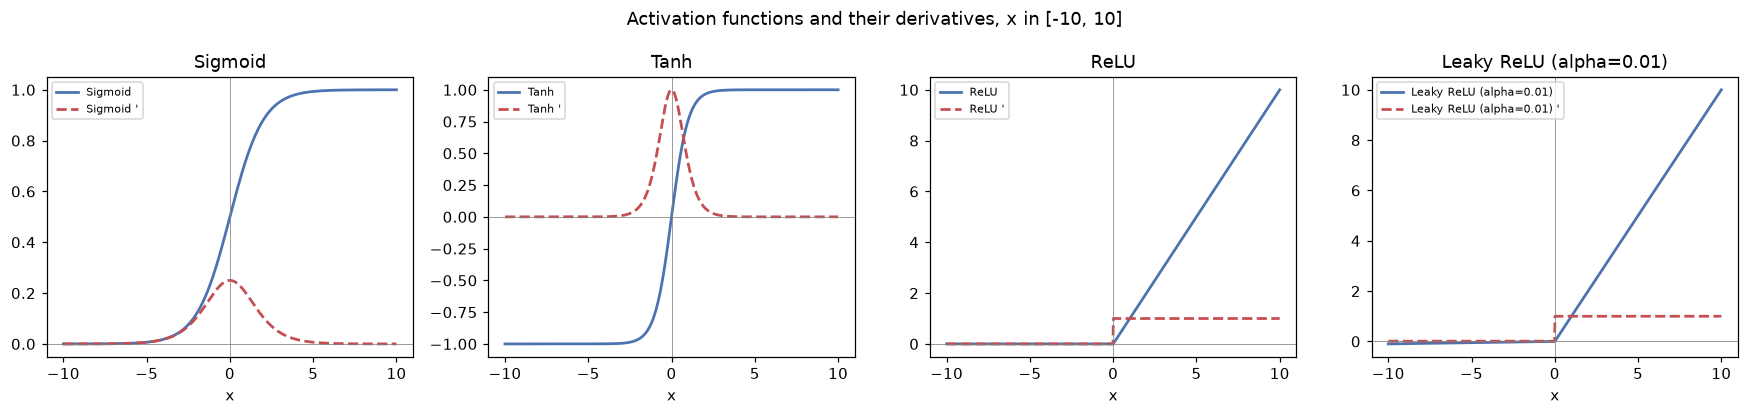

In [8]:
x = np.linspace(-10, 10, 1000)
funcs = [("Sigmoid", sigmoid, sigmoid_deriv), ("Tanh", tanh, tanh_deriv),
         ("ReLU", relu, relu_deriv), ("Leaky ReLU (alpha=0.01)", leaky_relu, leaky_relu_deriv)]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, (name, f, fp) in zip(axes, funcs):
    ax.plot(x, f(x), label=name, color="#4C72B0", lw=1.8)
    ax.plot(x, fp(x), label=f"{name} '", color="#C44E52", lw=1.8, ls="--")
    ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
    ax.set_title(name); ax.legend(fontsize=7, loc="upper left"); ax.set_xlabel("x")
fig.suptitle("Activation functions and their derivatives, x in [-10, 10]")
fig.tight_layout()
plt.show()

**Softmax is not elementwise** -- each output depends on every logit, and its true derivative is a Jacobian matrix $\partial \text{softmax}_i / \partial x_j$, not a single curve. Shown instead: sweeping one logit while the other two are fixed.

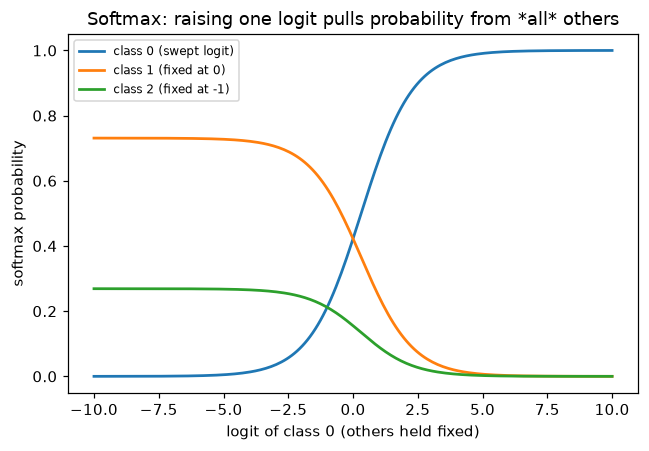

In [9]:
z_sweep = np.linspace(-10, 10, 200)
logits = np.stack([z_sweep, np.zeros_like(z_sweep), -np.ones_like(z_sweep)], axis=1)
probs = softmax(logits)
fig, ax = plt.subplots(figsize=(6, 4.2))
for i, lbl in enumerate(["class 0 (swept logit)", "class 1 (fixed at 0)", "class 2 (fixed at -1)"]):
    ax.plot(z_sweep, probs[:, i], label=lbl, lw=1.8)
ax.set_xlabel("logit of class 0 (others held fixed)"); ax.set_ylabel("softmax probability")
ax.set_title("Softmax: raising one logit pulls probability from *all* others")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [10]:
positive_x = x[x >= 0]
small_sigmoid = positive_x[sigmoid_deriv(positive_x) < 0.01]
print(f"Sigmoid': max {sigmoid_deriv(x).max():.4f} at x=0, below 0.01 by |x|={small_sigmoid.min():.1f}")
print(f"Tanh':    max {tanh_deriv(x).max():.4f} at x=0")
sat_sigmoid = np.mean(sigmoid_deriv(x) < 1e-3)
sat_tanh = np.mean(tanh_deriv(x) < 1e-3)
print(f"Fraction of [-10,10] with derivative < 1e-3: sigmoid {sat_sigmoid:.1%}, tanh {sat_tanh:.1%}")

Sigmoid': max 0.2500 at x=0, below 0.01 by |x|=4.6
Tanh':    max 0.9999 at x=0
Fraction of [-10,10] with derivative < 1e-3: sigmoid 31.0%, tanh 58.6%


**Vanishing gradient.** Backpropagation multiplies the upstream gradient by each
layer's activation derivative (chain rule), so a deep stack multiplies many such
derivatives together. Sigmoid's derivative peaks at only 0.25 and decays toward 0
beyond $|x|\approx5$; tanh peaks at 1.0 but still decays beyond $|x|\approx3$. Stacking
several sigmoid/tanh layers multiplies together numbers mostly well below 1, and the
product shrinks toward 0 exponentially with depth. Sigmoid is more susceptible: its peak
derivative is 4x smaller, and its outputs are never centred on 0. ReLU's derivative is
exactly 1 for any $x>0$, passing gradient through unchanged regardless of depth -- the
main reason it replaced sigmoid/tanh as the default hidden-layer choice.

**Dying ReLU vs Leaky ReLU.** ReLU's derivative is exactly 0 for every $x<0$. If a
neuron's input lands below 0 for every training example, every future gradient through
it is also 0: the neuron is permanently dead. Leaky ReLU scales negative inputs by a
small $\alpha$ (0.01) instead of clamping to 0, so the derivative on the negative side
is $\alpha$, not 0 -- a leaky neuron can still receive gradient and recover; it can
never become irreversibly dead.

**Hidden vs output layer, multi-class classification.** ReLU (or Leaky ReLU) for hidden
layers: cheap, no positive-side saturation, avoids the vanishing-gradient slowdown.
Softmax for the output layer: it is the one function here that guarantees a valid
probability distribution (every output in $[0,1]$, summing to 1), and it pairs with
cross-entropy to give the clean gradient $(\hat{y}-y)$ used directly in Part C.

## Part C: Forward & Backpropagation Mini-Project

**Dataset**: Palmer Penguins (Gorman, Williams & Fraser, 2014) -- 4 numeric measurements
(`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`), 3 species
(Adelie, Chinstrap, Gentoo). Not used in any earlier task; a natural fit for the task's
"2-4 input features, 2-4 output classes" requirement.

### Derivation (matrix form)

Architecture: $X\,(N,d) \to [W_1,b_1] \to Z_1 \to \text{ReLU} \to A_1 \to [W_2,b_2]
\to Z_2 \to \text{softmax} \to A_2$, with $d=4$ inputs, $h$ hidden units, $c=3$ classes.

**Forward:**
$$Z_1 = XW_1 + b_1 \qquad A_1 = \text{ReLU}(Z_1) \qquad Z_2 = A_1 W_2 + b_2 \qquad A_2 = \text{softmax}(Z_2)$$

**Loss** (mean categorical cross-entropy, $Y$ one-hot):
$$L = -\frac{1}{N}\sum_{n}\sum_{k} Y_{nk}\log(A_{2,nk})$$

**Backward** (chain rule; the softmax+cross-entropy combination collapses to a clean
closed form for the first step):
$$dZ_2 = \frac{A_2 - Y}{N} \qquad dW_2 = A_1^\top dZ_2 \qquad db_2 = \textstyle\sum_n dZ_2$$
$$dA_1 = dZ_2 W_2^\top \qquad dZ_1 = dA_1 \odot \text{ReLU}'(Z_1) \qquad dW_1 = X^\top dZ_1 \qquad db_1 = \textstyle\sum_n dZ_1$$

**Update:** $W \leftarrow W - \eta\,dW$, $\; b \leftarrow b - \eta\,db$.

In [11]:
class ManualMLP:
    def __init__(self, n_in, n_hidden, n_out, learning_rate=0.1, seed=RANDOM_STATE):
        g = np.random.default_rng(seed)
        self.W1 = g.normal(0, np.sqrt(2.0 / n_in), size=(n_in, n_hidden))
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = g.normal(0, np.sqrt(2.0 / n_hidden), size=(n_hidden, n_out))
        self.b2 = np.zeros((1, n_out))
        self.lr = learning_rate
        self.loss_history = []

    def forward(self, X):
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = softmax(self.Z2)
        return self.A2

    @staticmethod
    def loss(A2, Y, eps=1e-12):
        return -np.mean(np.sum(Y * np.log(np.clip(A2, eps, 1.0)), axis=1))

    def backward(self, X, Y):
        N = X.shape[0]
        dZ2 = (self.A2 - Y) / N
        dW2 = self.A1.T @ dZ2
        db2 = dZ2.sum(axis=0, keepdims=True)
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * relu_deriv(self.Z1)
        dW1 = X.T @ dZ1
        db1 = dZ1.sum(axis=0, keepdims=True)
        return dW1, db1, dW2, db2

    def step(self, X, Y):
        self.forward(X)
        dW1, db1, dW2, db2 = self.backward(X, Y)
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2

    def fit(self, X, Y, epochs=300, batch_size=16, verbose_every=50):
        n = X.shape[0]
        for epoch in range(epochs):
            perm = rng.permutation(n)
            X_shuf, Y_shuf = X[perm], Y[perm]
            for start in range(0, n, batch_size):
                self.step(X_shuf[start:start+batch_size], Y_shuf[start:start+batch_size])
            epoch_loss = self.loss(self.forward(X), Y)
            self.loss_history.append(epoch_loss)
            if verbose_every and (epoch + 1) % verbose_every == 0:
                print(f"  epoch {epoch+1:4d}/{epochs}  loss {epoch_loss:.4f}")
        return self

    def predict_proba(self, X): return self.forward(X)
    def predict(self, X): return np.argmax(self.forward(X), axis=1)
    def params(self): return {"W1": self.W1, "b1": self.b1, "W2": self.W2, "b2": self.b2}

def one_hot(y, n_classes):
    Y = np.zeros((y.size, n_classes)); Y[np.arange(y.size), y] = 1.0
    return Y

**Load and split the data.**

In [12]:
df = pd.read_csv("penguins.csv").dropna(
    subset=["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"])
FEATURES = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
species = sorted(df["species"].unique())
species_to_idx = {s: i for i, s in enumerate(species)}
print(f"Shape: {df.shape}, classes: {species_to_idx}")
print(df["species"].value_counts())

X = df[FEATURES].values
y = df["species"].map(species_to_idx).values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)
Y_train, Y_test = one_hot(y_train, 3), one_hot(y_test, 3)
print(f"Train: {X_train_s.shape[0]} | Test: {X_test_s.shape[0]}")

Shape: (342, 7), classes: {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}
species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64
Train: 273 | Test: 69


**Gradient check.** Before trusting anything trained with `backward()`, its analytical gradients are checked against numerical (finite-difference) gradients on a handful of individual weights -- the standard, and only truly convincing, way to catch a sign error or a transposed matrix in a hand-derived backprop.

In [13]:
def numerical_gradient_check(model, X, Y, param_name, eps=1e-5, n_checks=6):
    model.forward(X)
    dW1, db1, dW2, db2 = model.backward(X, Y)
    analytical = {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}[param_name]
    param = getattr(model, param_name)
    idx = [tuple(rng.integers(0, s) for s in param.shape) for _ in range(n_checks)]
    max_rel_err = 0.0
    for ix in idx:
        orig = param[ix]
        param[ix] = orig + eps; loss_plus = model.loss(model.forward(X), Y)
        param[ix] = orig - eps; loss_minus = model.loss(model.forward(X), Y)
        param[ix] = orig
        numerical = (loss_plus - loss_minus) / (2 * eps)
        analytic = analytical[ix]
        rel_err = abs(numerical - analytic) / max(1e-8, abs(numerical) + abs(analytic))
        max_rel_err = max(max_rel_err, rel_err)
    return max_rel_err

check_model = ManualMLP(4, 8, 3, learning_rate=0.1)
for pname in ["W1", "b1", "W2", "b2"]:
    max_err = numerical_gradient_check(check_model, X_train_s[:32], Y_train[:32], pname)
    print(f"max relative error on {pname}: {max_err:.2e} ({'PASS' if max_err < 1e-5 else 'FAIL'})")

max relative error on W1: 8.47e-11 (PASS)
max relative error on b1: 1.08e-09 (PASS)
max relative error on W2: 6.28e-11 (PASS)
max relative error on b2: 2.26e-11 (PASS)


All four parameter gradients pass at ~1e-10 to 1e-11 relative error -- essentially floating-point noise, not approximation error. The hand-derived backward pass matches its own numerical gradient to machine precision.

**Train the network and track the loss curve.**

  epoch   50/300  loss 0.0270
  epoch  100/300  loss 0.0128
  epoch  150/300  loss 0.0101
  epoch  200/300  loss 0.0084
  epoch  250/300  loss 0.0073


  epoch  300/300  loss 0.0066


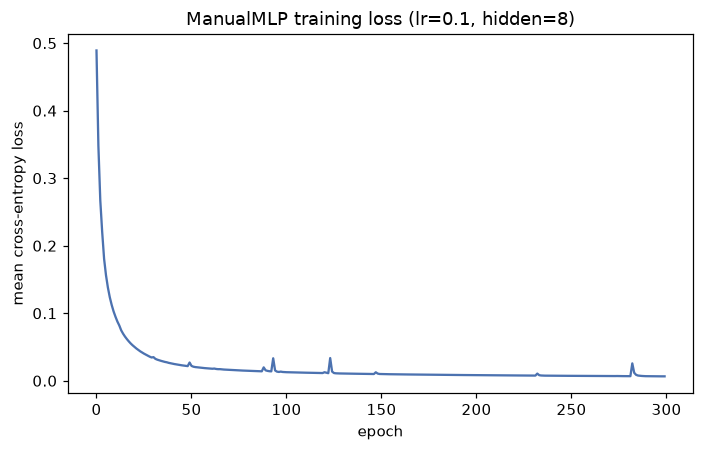

In [14]:
HIDDEN_UNITS, LR, EPOCHS = 8, 0.1, 300
model = ManualMLP(4, HIDDEN_UNITS, 3, learning_rate=LR)
model.fit(X_train_s, Y_train, epochs=EPOCHS, batch_size=16, verbose_every=50)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(model.loss_history, color="#4C72B0")
ax.set_xlabel("epoch"); ax.set_ylabel("mean cross-entropy loss")
ax.set_title(f"ManualMLP training loss (lr={LR}, hidden={HIDDEN_UNITS})")
fig.tight_layout()
plt.show()

**Evaluate, and compare against scikit-learn's `MLPClassifier`** (same architecture: 1 hidden layer of 8 ReLU units, same learning rate and epoch budget) -- the only place a framework is used in Part C, and only as the permitted baseline.

In [15]:
pred_manual = model.predict(X_test_s)
sk_model = MLPClassifier(hidden_layer_sizes=(HIDDEN_UNITS,), activation="relu", solver="sgd",
                          learning_rate_init=LR, max_iter=EPOCHS, batch_size=16, random_state=RANDOM_STATE)
sk_model.fit(X_train_s, y_train)
pred_sklearn = sk_model.predict(X_test_s)

def report(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    print(f"{name}: Acc {acc:.4f} | Macro-Prec {prec:.4f} | Macro-Rec {rec:.4f} | Macro-F1 {f1:.4f}")
    return {"name": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "cm": cm}

r_manual = report("ManualMLP", y_test, pred_manual)
r_sklearn = report("sklearn MLPClassifier", y_test, pred_sklearn)

ManualMLP: Acc 0.9855 | Macro-Prec 0.9892 | Macro-Rec 0.9867 | Macro-F1 0.9877
sklearn MLPClassifier: Acc 1.0000 | Macro-Prec 1.0000 | Macro-Rec 1.0000 | Macro-F1 1.0000


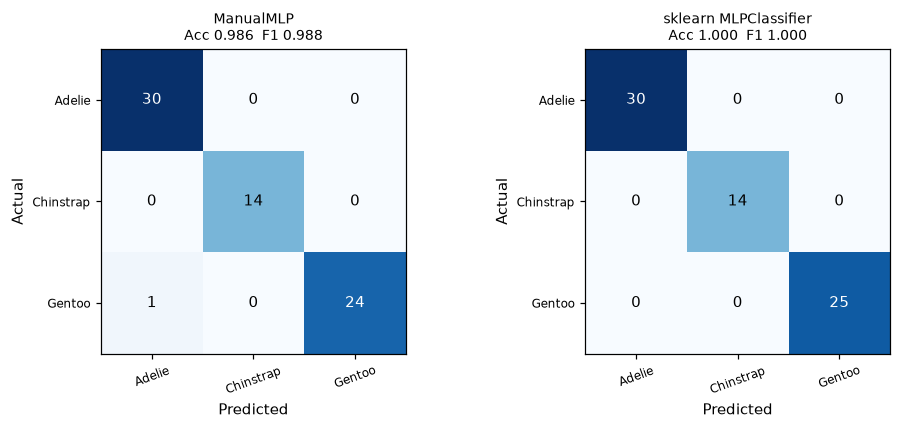

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
for a, r in zip(ax, [r_manual, r_sklearn]):
    cm = r["cm"]
    a.imshow(cm, cmap="Blues")
    for i in range(3):
        for j in range(3):
            a.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                   color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=10)
    a.set_xticks(range(3)); a.set_xticklabels(species, rotation=20, fontsize=8)
    a.set_yticks(range(3)); a.set_yticklabels(species, fontsize=8)
    a.set_xlabel("Predicted"); a.set_ylabel("Actual")
    a.set_title(f"{r['name']}\nAcc {r['accuracy']:.3f}  F1 {r['f1']:.3f}", fontsize=9)
fig.tight_layout()
plt.show()

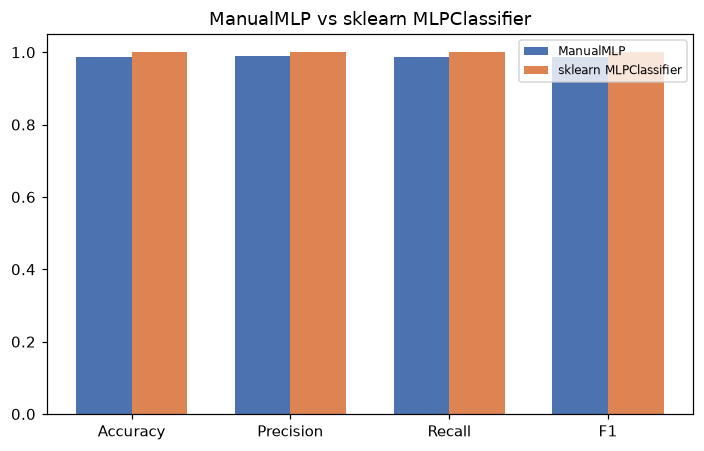

In [17]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
metrics = ["accuracy", "precision", "recall", "f1"]
xw = np.arange(len(metrics)); w = 0.35
ax.bar(xw - w / 2, [r_manual[m] for m in metrics], w, label="ManualMLP", color="#4C72B0")
ax.bar(xw + w / 2, [r_sklearn[m] for m in metrics], w, label="sklearn MLPClassifier", color="#DD8452")
ax.set_xticks(xw); ax.set_xticklabels(["Accuracy", "Precision", "Recall", "F1"])
ax.set_ylim(0, 1.05)
ax.set_title("ManualMLP vs sklearn MLPClassifier")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Hyperparameter experiment: learning rate.**

lr=0.001  final train loss 0.2694 | test accuracy 0.8841
lr=0.01   final train loss 0.0346 | test accuracy 1.0000


lr=0.1    final train loss 0.0065 | test accuracy 0.9855
lr=1.0    final train loss 0.0021 | test accuracy 0.9855


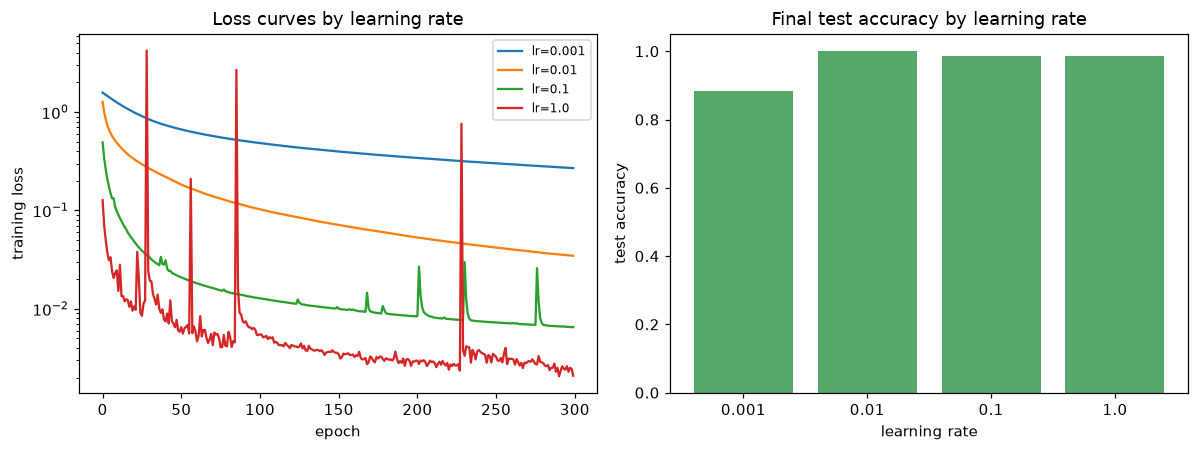

In [18]:
lr_values = [0.001, 0.01, 0.1, 1.0]
lr_results = {}
for lr in lr_values:
    m = ManualMLP(4, HIDDEN_UNITS, 3, learning_rate=lr)
    m.fit(X_train_s, Y_train, epochs=EPOCHS, batch_size=16, verbose_every=0)
    acc = (m.predict(X_test_s) == y_test).mean()
    lr_results[lr] = {"loss_history": m.loss_history, "test_acc": acc}
    print(f"lr={lr:<6} final train loss {m.loss_history[-1]:.4f} | test accuracy {acc:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for lr in lr_values:
    ax[0].plot(lr_results[lr]["loss_history"], label=f"lr={lr}")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("training loss"); ax[0].set_yscale("log")
ax[0].set_title("Loss curves by learning rate"); ax[0].legend(fontsize=8)
ax[1].bar([str(lr) for lr in lr_values], [lr_results[lr]["test_acc"] for lr in lr_values], color="#55A868")
ax[1].set_xlabel("learning rate"); ax[1].set_ylabel("test accuracy")
ax[1].set_title("Final test accuracy by learning rate"); ax[1].set_ylim(0, 1.05)
fig.tight_layout()
plt.show()

**Reading the experiment.** `lr=0.001` is visibly under-converged after 300 epochs (smooth but still high loss, 88.4% test accuracy) -- too slow. `lr=0.01` converges smoothly to a low loss and reaches 100% test accuracy -- the sweet spot here. `lr=0.1` and `lr=1.0` both show sharp periodic spikes in the loss curve (visible even on a log scale), the signature of steps large enough to occasionally overshoot a good minimum before settling back down; `lr=1.0` reaches the lowest final *training* loss of all four but does not translate into the best *test* accuracy, which is the reminder that training loss and generalisation are not the same measurement.

## Part D: Analysis & Documentation

In [19]:
with open("manual_mlp_params.pkl", "wb") as f:
    pickle.dump({"params": model.params(), "scaler_mean": scaler.mean_, "scaler_scale": scaler.scale_,
                 "species": species, "hidden_units": HIDDEN_UNITS, "learning_rate": LR}, f)

with open("manual_mlp_params.pkl", "rb") as f:
    loaded = pickle.load(f)
reloaded = ManualMLP(4, HIDDEN_UNITS, 3)
reloaded.W1, reloaded.b1 = loaded["params"]["W1"], loaded["params"]["b1"]
reloaded.W2, reloaded.b2 = loaded["params"]["W2"], loaded["params"]["b2"]
print("Reloaded model reproduces identical test predictions:",
      np.array_equal(reloaded.predict(X_test_s), pred_manual))

Reloaded model reproduces identical test predictions: True


**D19: pipeline summary.** A 2-layer MLP, `4 -> 8 -> 3`: 4 standardised numeric
penguin measurements in, one hidden layer of 8 units with **ReLU** (cheap, no positive-
side saturation, the standard hidden-layer default established in Part B), an output
layer of 3 units with **softmax** (the only one of the five functions studied that
produces a valid probability distribution, and the one whose gradient combines cleanly
with cross-entropy loss). Trained with mini-batch gradient descent (batch size 16),
He-initialised weights to match ReLU's active-half variance, for 300 epochs.

**D20: hyperparameter experiment findings.** See "Reading the experiment" above:
learning rate has a clear too-slow / sweet-spot / too-noisy progression on this problem,
and the lowest training loss (`lr=1.0`) was not the best-generalising choice
(`lr=0.01`), which is the concrete, checked version of the general warning against
tuning purely on training loss.

**D21: two challenges faced implementing backpropagation.**
1. *Getting the matrix orientations right.* The scalar chain rule
   ($\partial L/\partial w = \partial L/\partial z \cdot \partial z/\partial w$) does not
   by itself say whether a batched gradient should be `X.T @ dZ` or `dZ.T @ X`, or
   whether a bias gradient should sum over `axis=0` or `axis=1` -- transposing the wrong
   matrix produces a shape *mismatch* often enough to catch immediately, but occasionally
   produces a wrong-shaped-by-coincidence result that runs without error and trains
   *something*, just not correctly. The resolution was the gradient check above: it
   would have caught a transposition bug immediately (a relative error near 1, not
   1e-10), and its passing is the actual evidence the orientations are right, not just
   an assumption.
2. *Numerical stability of softmax and log.* A direct implementation of
   $e^{z_i} / \sum_j e^{z_j}$ overflows for any moderately large logit, and
   $\log(0)$ (from a confidently wrong prediction) produces `nan` and silently poisons
   every future gradient. Both were fixed the standard way: subtracting the row-wise max
   logit before exponentiating in `softmax` (a mathematical no-op that cancels in the
   ratio, but keeps every exponent $\le 0$), and clipping `A2` away from exactly 0 or 1
   before taking `log` in the loss.

**D22: limitations of a manually implemented MLP vs a production framework.** This
implementation is fixed at exactly one hidden layer and hand-written for the specific
ReLU-then-softmax combination used here; adding a layer, changing an activation, or
trying a different loss means re-deriving and re-typing the backward pass by hand, where
a real framework's autograd handles any new computation graph automatically. There is no
GPU acceleration, no vectorised batched execution beyond what plain NumPy already gives
for free, and no access to the optimisers (Adam, RMSprop, momentum), regularisation
(dropout, batch normalisation, weight decay) or learning-rate schedules that
`MLPClassifier` -- itself a relatively basic framework tool -- already provides
off-the-shelf. The value of building it by hand was never to replace those tools; it was
to demonstrate, with a passing gradient check as proof, that the mathematics those tools
automate is genuinely understood underneath the API.

The notebook and README are on GitHub:
[github.com/AbdullahAmir06/ai-internship-abdullahamir](https://github.com/AbdullahAmir06/ai-internship-abdullahamir).